# Part 6 — Supervised Fine-Tuning: A Walkthrough

## Think of it as a new hire's first week 💼

Before any code, here's the one picture that explains this entire notebook. Keep it in your head the whole way through:

> By the end of Part 4 our student **graduated**. It reads fluently and talks fluently — give it any half-sentence and it finishes it smoothly. But it has a problem: it doesn't know that a **question** is a request for an **answer**, and it doesn't know *when to stop talking*. Ask it *"What is the first prime number?"* and it might just continue *"...is a question often asked in school, and many students wonder..."*. It read the whole internet, so it keeps writing whatever plausibly comes next.
>
> **Part 6 is the new hire's first week on the job.** The student already has all the knowledge and language skill — now it gets *job training*: here's the format we use to talk to customers, here's where the customer's question ends and **your answer begins**, and here's the one rule that matters most — **you are graded on your answers, never on the customer's questions.**

That last rule is the whole soul of this part. Swap a few words and you have the real thing:

| On the job (new hire) | In SFT (the code) | Section |
|---|---|---|
| the standard message format everyone uses | the **chat template** | 6.1 |
| "start of memo" / "end of memo" stamps | **special tokens** (`<s>` start, `</s>` stop) | 6.1 |
| the customer's question | the **prompt** | 6.2 |
| the new hire's reply (what we're training) | the **response** | 6.2 |
| **"grade the reply, never the question"** | **loss masking** — prompt labels set to `-100` | **6.3 ⭐** |
| start with easy tickets, work up to hard ones | **length curriculum** | 6.4 |
| same study habits as training school | **reuse Part 4's loop** | 6.5 |
| the new hire handling a real ticket | **sampling** with the template | 6.6 |
| the performance review | **evaluation** (exact match, token-F1) | 6.7 |

**Why this part exists:** a raw pretrained model is a brilliant autocomplete, not an assistant. SFT is the cheapest, most direct way to turn "finishes any text" into "answers the question and stops." It's the first step of *alignment* — Parts 6→9 are all about shaping *what* the fluent model chooses to say.

**What you should know going in:**
- Part 4 is fresh: BPE tokenizer, the training loop (AdamW, cross-entropy, checkpoints).
- Part 2's next-token idea: the model always predicts "what comes next."
- You've seen sampling (temperature / top-k) from Part 2.

**What you'll build, step by step:**
1. **6.1** the company format — wrap every example in a fixed skeleton
2. **6.2** the stack of tickets — load (instruction, response) pairs
3. **6.3** the one rule — grade the answer, never the question *(the heart of Part 6)*
4. **6.4** easy tickets first — order examples short→long
5. **6.5** same study habits — reuse Part 4's loop, starting from the graduate
6. **6.6** handling a real ticket — sample with the template, stop on `</s>`
7. **6.7** the performance review — score answers against gold replies

**One running example everywhere** — a tiny instruction with a tiny answer:

> **instruction:** `First prime number`  →  **response:** `2`

It's deliberately small so the masking arrays fit on one screen — and it's literally one of the fallback examples baked into `dataset_sft.py`, so every cell runs with no downloads.


## The Map

Here's the whole first week as a flowchart. You'll see this same diagram at the top of every section, with the step we're on lit up in green and the rest greyed out — so you always know where you are.

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style mask fill:#e8e8e8,stroke:#bbb,color:#777
    style cur fill:#e8e8e8,stroke:#bbb,color:#777
    style load fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style samp fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

Reading it as a new hire's week:
1. a training example is a **raw pair** — a question and its correct answer
2. we wrap it in the **chat format** (6.1) so question and answer are clearly marked
3. we **tokenize** it into ids (6.2–6.3), like every part before
4. we **mask the prompt** (6.3) — cross out the question so only the answer is graded ⭐
5. we **load the Part 4 graduate** and feed examples **easy→hard** (curriculum, 6.4)
6. we **train** with the *same* loop as Part 4 (6.5) — only the masking is new
7. finally the trained model **answers real tickets** (6.6) and we **review** them (6.7)

**Where this sits in the whole course:** the model itself does not change in Part 6 — it's the same `GPTModern` from Part 3, trained the same way as Part 4. What changes is the **data** (pairs, not raw text) and **which predictions count** (answers only). That's it. SFT is a small, surgical change with an outsized effect.

**The single most important idea in this part:** **grade the answer, never the question.** Every token that belongs to the prompt gets the label `-100`, and PyTorch's cross-entropy silently skips any `-100`. So all the learning pressure lands on *the reply*. Hold onto that — section 6.3 is built entirely around it.


## Setup

Run this cell once. This notebook lives inside `part_6/`. We add `part_6/` (its own modules), plus `part_3/` and `part_4/` (the model and tokenizer it reuses), to the path.


In [2]:
import sys, pathlib

NB_DIR = pathlib.Path().resolve()                 # .../part_6
PART_3 = NB_DIR.parent / "part_3"                  # GPTModern, ByteTokenizer
PART_4 = NB_DIR.parent / "part_4"                  # BPE tokenizer (optional)
for p in (str(NB_DIR), str(PART_3), str(PART_4)):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

torch.manual_seed(0)
np.set_printoptions(precision=3, suppress=True)

print("Setup complete. Working directory:", NB_DIR.name)


Setup complete. Working directory: part_6


### Our running example

We carry one tiny instruction/response pair through the whole notebook. Everything you see — the formatting, the masking, the training step — uses this exact pair so you can follow a single thread end to end.


In [3]:
# The anchor example for Part 6 (one of dataset_sft.py's own fallback seeds)
INSTR = "First prime number"
RESP  = "2"

print("instruction:", repr(INSTR))
print("response   :", repr(RESP))


instruction: 'First prime number'
response   : '2'


---
## 6.1 Speaking the Company Format (the Chat Template)

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style mask fill:#e8e8e8,stroke:#bbb,color:#777
    style cur fill:#e8e8e8,stroke:#bbb,color:#777
    style load fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style samp fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 4 memory:** the tokenizer turned text into chunks; structure was just a flat stream of characters.
>
> **Part 6 now:** we wrap every (question, answer) pair in a fixed skeleton with clear markers, so the model can tell *where the question ends and the answer begins*.
>
> **Returns later:** Part 7's preference pairs reuse this exact template for both the "chosen" and "rejected" answers.

### What we're doing here, and why

Before the new hire writes a single reply, they learn the **one format** every message uses. It marks three things: where the **question** is, where the **answer** goes, and — crucially — where the answer **ends**.

That's all `formatters.py` does. It's pure string formatting, no math. One fixed template:

```text
<s>
### Instruction:
{instruction}

### Response:
{response}</s>
```

- `<s>` and `</s>` are "start of memo" / "end of memo" stamps. The `</s>` is the **stop** signal — we're going to train the model to emit it so it knows when to shut up.
- `### Instruction:` and `### Response:` are signposts that separate the question from the answer.

There are two helpers, and the difference between them is the seed of everything in 6.3:
- `format_example(...)` fills in **both** the instruction and the response — this is a complete *training* example.
- `format_prompt_only(...)` fills in **only the instruction** and stops right at `### Response:` — this is what we hand the model at *inference* time, then let it write the rest.

### Let's format our example both ways


In [4]:
from formatters import Example, format_example, format_prompt_only

full   = format_example(Example(INSTR, RESP))
prompt = format_prompt_only(INSTR)

print("format_example  (the full TRAINING example):")
print(full)
print("\n" + "-" * 50 + "\n")
print("format_prompt_only  (what we feed at INFERENCE time):")
print(prompt)


format_example  (the full TRAINING example):
<s>
### Instruction:
First prime number

### Response:
2</s>

--------------------------------------------------

format_prompt_only  (what we feed at INFERENCE time):
<s>
### Instruction:
First prime number

### Response:
</s>


### Spot the divergence — this is the seed of masking

Look at the two strings as raw text (`repr` makes the line breaks visible as `\n`). They are **identical** up to and including `### Response:\n`. Then they split: the full example continues with the answer `2</s>`, while the prompt-only version just *stops*.

That shared boundary — "everything up to `### Response:`" — is exactly the line we'll draw in 6.3 between *the question* (don't grade) and *the answer* (grade).


In [5]:
full_r   = repr(full)
prompt_r = repr(format_prompt_only(INSTR).replace("</s>", ""))   # the collator drops the trailing </s>

# Find how much of the two strings is a shared prefix
a = full
b = format_prompt_only(INSTR).replace("</s>", "")
common = 0
for ca, cb in zip(a, b):
    if ca != cb:
        break
    common += 1

print("full example  :", full_r)
print("prompt prefix :", prompt_r)
print()
print(f"shared prefix length: {common} characters")
print(f"the prompt prefix is: {repr(b)}")
print(f"everything AFTER that is the answer: {repr(a[common:])}")


full example  : '<s>\n### Instruction:\nFirst prime number\n\n### Response:\n2</s>'
prompt prefix : '<s>\n### Instruction:\nFirst prime number\n\n### Response:\n'

shared prefix length: 55 characters
the prompt prefix is: '<s>\n### Instruction:\nFirst prime number\n\n### Response:\n'
everything AFTER that is the answer: '2</s>'


**Gotcha worth knowing:** `<s>` and `</s>` are just *literal text* here — five and four ordinary characters. They are **not** magic tokens the model understands by default. The `</s>` only *becomes* a stop signal because (a) we put it at the end of every training answer, so the model learns to produce it, and (b) at generation time `generate()` watches for it and halts (we'll see this in 6.6). The signposts work because we're consistent, not because they're special.


---
## 6.2 The Stack of Tickets (the SFT Dataset)

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style mask fill:#e8e8e8,stroke:#bbb,color:#777
    style cur fill:#e8e8e8,stroke:#bbb,color:#777
    style load fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style samp fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 2 memory:** the dataset was one long text, sliced into next-token windows.
>
> **Part 6 now:** the dataset is a stack of discrete **(instruction, response) pairs** — tickets, not a river of text.
>
> **Returns later:** Part 7 upgrades each item to a *triple* — prompt + a "chosen" answer + a "rejected" answer.

### What we're doing here, and why

Training school (Part 4) fed the student raw text with a single instruction: *predict the next character*. On the job, every training example is a **pair**: a question and the correct reply. That's the paradigm shift — from an endless stream of text to a stack of question/answer cards.

`dataset_sft.py` does exactly this. It *tries* to download a tiny slice of a real instruction dataset (`tatsu-lab/alpaca`), and if that library isn't available it falls back to three baked-in pairs. We'll use the fallback so this runs anywhere with no download.


In [6]:
from dataset_sft import load_tiny_hf, SFTItem

# sample_dataset=True forces the baked-in fallback (no network needed)
items = load_tiny_hf(sample_dataset=True)

print(f"Loaded {len(items)} (instruction, response) pairs:\n")
for it in items:
    print(f"  Q: {it.prompt!r}")
    print(f"  A: {it.response!r}")
    print()


Couldn't import `datasets`. Will use fallback data only.
Loaded 3 (instruction, response) pairs:

  Q: 'First prime number'
  A: '2'

  Q: 'What are the three primary colors?'
  A: 'red'

  Q: 'Device name which points to direction?'
  A: 'compass'



When the real dataset *is* available, each raw row looks like `{instruction, input, output}`. The loader folds any extra `input` into the instruction (joined with a newline) and uses `output` as the response — collapsing the three fields into our simple `SFTItem(prompt, response)`. Rows with an empty instruction or empty answer are skipped (an empty answer would have *nothing to grade* — see 6.3).

### The shift, in one table

| | Part 2 / 4 (`dataset.py`) | Part 6 (`dataset_sft.py`) |
|---|---|---|
| unit of data | one long text | discrete (instruction, response) pairs |
| what's predicted | the next token, **everywhere** | the next token, **answer only** |
| masking? | none | yes — the prompt is masked out (6.3) |

Same model, same next-token game underneath — but the data is now shaped like a conversation, and that reshaping is what lets masking do its job.


---
## 6.3 Grade the Answer, Never the Question (Loss Masking) ⭐

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style mask fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style cur fill:#e8e8e8,stroke:#bbb,color:#777
    style load fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style samp fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 4 memory:** every position contributed to the loss — predict the next token, everywhere, all the time.
>
> **Part 6 now:** only **response** positions are graded. Every prompt token gets the label `-100`, and cross-entropy skips it. Grade the answer, never the question.
>
> **Returns later:** Parts 8–9 drop the fixed gold answer entirely — the "grade" becomes a *reward* from a learned model instead of a copied label.

### What we're doing here, and why

This is the one idea that makes SFT *SFT*.

A manager reviewing the new hire's email reply reads the customer's question for **context** — but they'd never dock points because the customer wrote *"whats the frist prime nuber??"*. They only grade the **reply**.

Loss masking is that exact policy, written as code. We line up the model's prediction at every position against the correct next token. Then, for every position that belongs to the **question**, we replace the label with `-100`. PyTorch's cross-entropy treats `-100` as "skip this one — no grade, no gradient." So all the learning pressure lands on the **answer**.

To make every token visible on screen, we'll trace with the **byte tokenizer** (one character = one token). With Part 4's BPE the idea is identical — the boxes are just wider and fewer.

### Let's build the real collator and run our example through it


In [7]:
from collator_sft import SFTCollator
from tokenizer import ByteTokenizer     # Part 3's byte tokenizer (vocab = 256)

# Build the REAL SFTCollator, but hand it the byte tokenizer so every token is one
# visible character. (We use __new__ to skip the BPE auto-detect in __init__; the
# collate() logic we're studying is identical either way.)
col = SFTCollator.__new__(SFTCollator)
col.block_size = 64
col.tok = ByteTokenizer()

x, y = col.collate([(INSTR, RESP)])     # one example -> (1, block_size) tensors

print("input_ids x:", tuple(x.shape))
print("labels    y:", tuple(y.shape))
print()
print("graded positions (label != -100):", int((y[0] != -100).sum()))
print("ignored positions (label == -100):", int((y[0] == -100).sum()), "(prompt + padding)")


input_ids x: (1, 64)
labels    y: (1, 64)

graded positions (label != -100): 5
ignored positions (label == -100): 59 (prompt + padding)


### The picture that explains all of SFT

Below is the real `(input_ids, labels)` for our example, position by position. The long run of question tokens is collapsed (it's all `-100`); we zoom in on the boundary where the answer begins.

Three things to look for, in order:

1. **`labels` is `input_ids` shifted by one.** At each spot the label is *the token that comes next* — the next-token game from Part 2, unchanged. So `y[t] = x[t+1]`.
2. **The whole question is crossed out** — every prompt position shows `IGNORED` (`-100`).
3. **The first graded position is the last prompt token**, because *its* "next token" is the first letter of the answer. That's where grading starts — not one token sooner.


In [8]:
# Recompute the prompt boundary exactly the way collate() does
prefix_text = format_prompt_only(INSTR).replace("</s>", "")
ids_full = col.encode(format_example(Example(INSTR, RESP)))
n_prompt = min(len(col.encode(prefix_text)), len(ids_full))
real_len = len(ids_full)

x0, y0 = x[0].tolist(), y[0].tolist()
first_graded = next(t for t in range(real_len) if y0[t] != -100)

# Show first few prompt rows, an ellipsis for the masked middle, then the boundary + answer + a little padding
detail = set(range(0, 2)) | set(range(n_prompt - 2, real_len + 3))
print(f"{'pos':>4}  {'input char':<12} {'-> label (next)':<18} graded?")
print("-" * 52)
ell = False
for t in range(real_len + 3):
    if t not in detail:
        if not ell:
            print(f"  ..   (positions 2..{n_prompt-3}: rest of the QUESTION, all IGNORED)")
            ell = True
        continue
    is_pad = t >= real_len
    inp = "PAD" if is_pad else repr(chr(x0[t]))
    lab = "IGNORED" if y0[t] == -100 else repr(chr(y0[t]))
    mark = ""
    if y0[t] != -100:
        mark = "  <= FIRST graded" if t == first_graded else "  YES"
    print(f"{t:>4}  {inp:<12} -> {lab:<15} {mark}")

print()
print(f"prompt boundary n_prompt = {n_prompt}   ->  first graded index = {first_graded}  (= n_prompt - 1)")


 pos  input char   -> label (next)    graded?
----------------------------------------------------
   0  '<'          -> IGNORED         
   1  's'          -> IGNORED         
  ..   (positions 2..52: rest of the QUESTION, all IGNORED)
  53  ':'          -> IGNORED         
  54  '\n'         -> '2'               <= FIRST graded
  55  '2'          -> '<'               YES
  56  '<'          -> '/'               YES
  57  '/'          -> 's'               YES
  58  's'          -> '>'               YES
  59  '>'          -> IGNORED         
  60  PAD          -> IGNORED         
  61  PAD          -> IGNORED         
  62  PAD          -> IGNORED         

prompt boundary n_prompt = 55   ->  first graded index = 54  (= n_prompt - 1)


### Picture it — question vs answer

Grey = the question (ignored, `-100`). Green = the answer (graded). The dashed line is the boundary `n_prompt − 1`, the exact spot where grading switches on. Everything to the right of it — and nothing to the left — teaches the model.


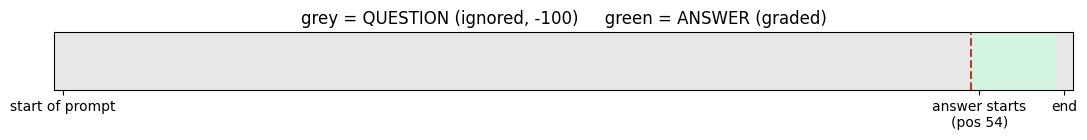

In [9]:
mask_row = np.array([[0 if v == -100 else 1 for v in y0[:real_len]]])

fig, ax = plt.subplots(figsize=(11, 1.5))
ax.imshow(mask_row, aspect="auto", cmap=ListedColormap(["#e8e8e8", "#d5f5e3"]), vmin=0, vmax=1)
ax.axvline(first_graded - 0.5, color="#c0392b", ls="--", lw=1.5)
ax.set_yticks([])
ax.set_xticks([0, first_graded, real_len - 1])
ax.set_xticklabels(["start of prompt", f"answer starts\n(pos {first_graded})", "end"])
ax.set_title("grey = QUESTION (ignored, -100)     green = ANSWER (graded)")
plt.tight_layout(); plt.show()


### The bookkeeping (optional)

If you want to see the exact label construction, here are the four lines from `collator_sft.py` that build `y` for one example:

```python
n_prompt = min(len(prompt_ids), len(ids))   # where the answer starts
for t in range(len(y) - 1):  y[t] = ids[t + 1]   # 1) shift left: label = next token
y[-1] = -100                                     # 2) nothing to predict after the end
for i in range(n_prompt - 1):  y[i] = -100       # 3) cross out the QUESTION
```

The one detail people trip on is that last loop: it's `range(n_prompt - 1)`, **not** `range(n_prompt)`. Position `n_prompt − 1` (the prompt's final token) is left **un-masked**, because its *target* is the answer's first token. The new hire is graded starting from the very first word of their reply — and not one token sooner. (Padding, added afterwards, fills `x` with a pad id and `y` with `-100`, so padded positions never count either.)

### Prove it — the graded tokens are exactly the answer

If masking works, the labels left for grading should be **exactly the answer's tokens** — the answer text plus the `</s>` stop token — and every question position should be `-100`. (Notice the model *is* graded on emitting `</s>`: that's literally how it learns *when to stop*.) Let's confirm both — the same kind of check `tests/test_masking.py` runs.


In [10]:
# The graded labels should be EXACTLY the answer's tokens (the answer + the </s> stop)
graded_labels = [v for v in y0 if v != -100]
answer_tokens = col.encode(RESP + "</s>")          # ids for "2</s>"

print("answer + stop token :", repr(RESP + "</s>"))
print("its token ids       :", answer_tokens)
print("graded label ids    :", graded_labels, "  <- identical")
print("graded labels decode:", repr(col.tok.decode(graded_labels)))
print()
print(f"all {first_graded} question positions are -100:", all(v == -100 for v in y0[:first_graded]))


answer + stop token : '2</s>'
its token ids       : [50, 60, 47, 115, 62]
graded label ids    : [50, 60, 47, 115, 62]   <- identical
graded labels decode: '2</s>'

all 54 question positions are -100: True


### Why it matters (simple → practical → deeper)

- **Simple:** if we graded the question too, the model would waste effort learning to *re-type questions* instead of *answer* them.
- **Practical:** masking lets a single short example teach format, content, and stopping all at once — without a long prompt drowning out the signal from a one-word answer.
- **Deeper:** SFT is still plain next-token prediction — the *same loss* as Part 2 and Part 4. Masking doesn't change the math at all; it only **chooses which predictions count**. That's the whole reason the Part 4 training loop drops in here unchanged (next section).


---
## 6.4 Easy Tickets First (the Length Curriculum)

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style mask fill:#e8e8e8,stroke:#bbb,color:#777
    style cur fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style load fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style samp fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 4 memory:** the learning-rate schedule paced *how hard* we corrected (warm up, then cool down).
>
> **Part 6 now:** the curriculum paces *what we study* — short prompts first, longer ones later.
>
> **Returns later:** once rewards drive training (Parts 8–9), prompts are sampled more freely and ordering tricks like this fade.

### What we're doing here, and why

A good manager hands the new hire short, simple tickets on Monday and works up to the long, tangled ones by Friday. `curriculum.py` does exactly that with one line of sorting: order the pairs by **prompt length**, shortest first, so the model warms up on easy structure before hard instructions.


In [11]:
from curriculum import LengthCurriculum

pairs = [(it.prompt, it.response) for it in items]

print("original order (with prompt lengths):")
for p, r in pairs:
    print(f"  len={len(p):2d}  {p!r}")

ordered = list(LengthCurriculum(pairs))
print("\ncurriculum order (short -> long):")
for p, r in ordered:
    print(f"  len={len(p):2d}  {p!r}  ->  {r!r}")


original order (with prompt lengths):
  len=18  'First prime number'
  len=34  'What are the three primary colors?'
  len=38  'Device name which points to direction?'

curriculum order (short -> long):
  len=18  'First prime number'  ->  '2'
  len=34  'What are the three primary colors?'  ->  'red'
  len=38  'Device name which points to direction?'  ->  'compass'


**Two gotchas worth knowing:**
- It sorts on raw **character** length (`len(prompt)`), not token count — a cheap, good-enough proxy. A long word that BPE compresses into one chunk still counts as "long" here.
- It's a **single-pass** iterator (one trip short→long). `train_sft.py` calls `list(...)` on it so it can slice batches, and simply restarts from the top when it runs out.

It's the lightest-weight idea in the part — but a real lever in practice: easy-first ordering often makes early training noticeably smoother.


---
## 6.5 Same Study Habits, New Material (the SFT Training Loop)

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style mask fill:#e8e8e8,stroke:#bbb,color:#777
    style cur fill:#e8e8e8,stroke:#bbb,color:#777
    style load fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style train fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style samp fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 4 memory:** the full study session — AdamW, cross-entropy, checkpoints, a progress chart.
>
> **Part 6 now:** the *same* loop, with two changes: we **start from the graduated checkpoint**, and the grading step **ignores the masked `-100` positions** automatically.
>
> **Returns later:** Part 8 wraps a loop like this inside a reinforcement-learning outer loop (sample → score → update).

### What we're doing here, and why

Here's the relief: **we don't reinvent training.** The new hire studies the *same way* it did in school — guess, grade, correct, repeat, with AdamW and a learning rate. Compared to Part 4, only two things differ:

1. We **load the Part 4 graduate** instead of starting from a blank brain (`--ckpt` in `train_sft.py`). The model already speaks; we're only teaching format and stopping.
2. The loss is computed on the masked labels from 6.3, so **only response tokens are graded** — and that happens for free, because `GPTModern`'s `F.cross_entropy` already ignores `-100`.

Below we run **one real training step** on a tiny model to watch the shapes flow and the masked loss come out. We use a fresh random model (no checkpoint needed to see the mechanics); the real run starts from the Part 4 checkpoint.


In [12]:
from model_modern import GPTModern

# A tiny model so one step runs instantly on CPU. vocab_size=256 matches the byte tokenizer.
# n_embd=32, n_head=2 -> head dim 16 (even, required by RoPE).
torch.manual_seed(0)
model = GPTModern(vocab_size=256, block_size=64, n_layer=2, n_head=2, n_embd=32,
                  use_rmsnorm=True, use_swiglu=True, rope=True)

# Build a small batch with the SAME byte collator from 6.3
batch = ordered[:2]                         # two examples, easy-first
xb, yb = col.collate(batch)
print("batch:", [p for p, _ in batch])
print("xb:", tuple(xb.shape), " yb:", tuple(yb.shape))

# --- one training step (the Part 4 rhythm: forward -> loss -> backward -> update) ---
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
model.train()

logits, loss, _ = model(xb, yb)             # forward: GPTModern returns (logits, loss, caches)
opt.zero_grad(set_to_none=True)
loss.backward()                             # gradients flow ONLY from graded (response) tokens
opt.step()

print()
print("logits:", tuple(logits.shape), " (B, T, vocab)")
print(f"masked loss: {loss.item():.4f}")
print("grad on token-embedding exists:", model.tok_emb.weight.grad is not None)


batch: ['First prime number', 'What are the three primary colors?']
xb: (2, 64)  yb: (2, 64)

logits: (2, 64, 256)  (B, T, vocab)
masked loss: 5.9892
grad on token-embedding exists: True


### What just happened — in plain words

| Code | New-hire translation |
|---|---|
| `xb, yb = col.collate(batch)` | turn a few tickets into ids, with the questions crossed out |
| `logits, loss, _ = model(xb, yb)` | the new hire guesses every next token; we grade **only the answers** |
| `loss.backward()` | work out which way to nudge every weight to answer a little better |
| `opt.step()` | make the nudge |

### Shape trace

| Stage | Shape |
|---|---|
| `xb` (input ids) | `(B, T)` = `(2, 64)` |
| `logits` | `(B, T, vocab)` = `(2, 64, 256)` |
| flattened for loss | `(B*T, vocab)` = `(128, 256)` vs targets `(128,)` |
| after dropping `-100` | only the answer positions remain |
| `loss` | a single scalar |

**One thing to expect:** the SFT loss usually starts *lower* than Part 4's pretraining loss. Two reasons — most positions are masked out (so we're averaging over far fewer, easier predictions), and the model already speaks fluently. It's polishing *format and stopping*, not learning language from scratch.

**Checkpoint gotcha:** `--ckpt` loads the saved **weights**, but the architecture comes from the command-line args. If they disagree (say, a 2-layer checkpoint into a 4-layer model), it fails at the forward pass. And the model's `vocab_size` must match the collator's tokenizer — byte (256) vs BPE (~8000).


---
## 6.6 Handling a Real Ticket (Sampling with the Chat Template)

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style mask fill:#e8e8e8,stroke:#bbb,color:#777
    style cur fill:#e8e8e8,stroke:#bbb,color:#777
    style load fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style samp fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 2 memory:** sampling with temperature / top-k let the student "write on its own."
>
> **Part 6 now:** same sampling — but we feed the chat template *up to* `### Response:` and trust the model to write the answer and emit `</s>` to stop.
>
> **Returns later:** Part 7 generates *several* answers per prompt so a human (or a reward model) can rank them.

### What we're doing here, and why

Exam time, on-the-job edition. We wrap the user's question in the **same** format the model trained on — up to `### Response:\n` and **no further** — then let it generate. Because we taught it to end answers with `</s>`, it now has a way to say "I'm done" instead of rambling forever (`generate()` stops early when it produces the end token, `eos_id=1`).

`sample_sft.py` does exactly this. Below we run the real generation path on our tiny model. The model is untrained here, so the *words* will be gibberish — what we're watching is the **plumbing**: format the prompt, feed it in, generate, decode, stop. (Real answers need the Part 4 checkpoint; see the demo command at the end.)


In [13]:
from formatters import format_prompt_only

# 1) format the prompt the SAME way as training, then drop the trailing </s>
prompt_text = format_prompt_only(INSTR).replace("</s>", "")
idx = torch.tensor([col.encode(prompt_text)], dtype=torch.long)
print("prompt fed to the model (repr):", repr(prompt_text))
print("prompt ids shape:", tuple(idx.shape))

# 2) generate -- same call sample_sft.py makes (mechanics only; model is untrained)
model.eval()
with torch.no_grad():
    out = model.generate(idx, max_new_tokens=24, temperature=0.8, top_k=5)

print("output ids shape:", tuple(out.shape), " (prompt + generated)")

# 3) decode just the generated continuation
gen_ids = out[0].tolist()[idx.shape[1]:]
print("\ngenerated continuation (gibberish from an untrained model — that's expected):")
print(repr(col.tok.decode(gen_ids)))


prompt fed to the model (repr): '<s>\n### Instruction:\nFirst prime number\n\n### Response:\n'
prompt ids shape: (1, 55)
output ids shape: (1, 79)  (prompt + generated)

generated continuation (gibberish from an untrained model — that's expected):
'6hW^#\x14\x17όreI5G'


**What to notice (the mechanics, not the words):**
- The prompt we feed ends exactly at `### Response:\n` — we never feed the answer or the `</s>`; producing those is the model's job.
- `generate` appends one token at a time onto the prompt (`output = prompt + generated`).
- `temperature=0.2` (the default in `sample_sft.py`) keeps it nearly greedy — picking the most likely token — which is what you want once a model actually knows the answer.
- `eos_id=1` lets a *trained* model stop on its own when it emits `</s>`. A well-fine-tuned model answers, emits the stop token, and goes quiet — the whole point of teaching the format.


---
## 6.7 The Performance Review (Evaluation)

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#e8e8e8,stroke:#bbb,color:#777
    style fmt fill:#e8e8e8,stroke:#bbb,color:#777
    style tok fill:#e8e8e8,stroke:#bbb,color:#777
    style mask fill:#e8e8e8,stroke:#bbb,color:#777
    style cur fill:#e8e8e8,stroke:#bbb,color:#777
    style load fill:#e8e8e8,stroke:#bbb,color:#777
    style train fill:#e8e8e8,stroke:#bbb,color:#777
    style samp fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

> **Part 4 memory:** validation *loss* told us whether the student could predict held-out text.
>
> **Part 6 now:** we score the model's *actual generated answers* against gold replies — measuring quality, not just loss.
>
> **Returns later:** in Part 7 this kind of scoring *becomes the training signal* — a learned reward model replaces these simple string metrics.

### What we're doing here, and why

How do we know the new hire is actually good? We compare their reply to the gold answer with two lenient yardsticks (`evaluate.py`). These never touch training — they're the review *after* the work:

- **exact match** — after tidying case and punctuation, is the answer *exactly* the gold string? (1.0 or 0.0)
- **token-F1** — how much do the words overlap, regardless of order? (a softer, partial-credit score)


In [14]:
from evaluate import exact_match, token_f1, _normalize

print("normalization lowercases and strips punctuation:")
print("  ", repr("The first prime is 2!"), "->", repr(_normalize("The first prime is 2!")))
print()

print("exact_match:")
print("  pred='2'                  gold='2'  ->", exact_match("2", "2"))
print("  pred='The answer is 2.'   gold='2'  ->", exact_match("The answer is 2.", "2"))
print()

print("token_f1 (partial credit by word overlap):")
print("  pred='What's learning'  gold='What is learning'  ->", round(token_f1("What's learning", "What is learning"), 3))


normalization lowercases and strips punctuation:
   'The first prime is 2!' -> 'the first prime is 2'

exact_match:
  pred='2'                  gold='2'  -> 1.0
  pred='The answer is 2.'   gold='2'  -> 0.0

token_f1 (partial credit by word overlap):
  pred='What's learning'  gold='What is learning'  -> 0.667


### The bookkeeping (optional)

Token-F1 is the same F1 you may know, applied to the *bag of words*:

$$\text{precision} = \frac{\text{matching words}}{\text{words in the prediction}} \qquad \text{recall} = \frac{\text{matching words}}{\text{words in the gold answer}} \qquad F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$

For `pred = "What's learning"` vs `gold = "What is learning"`:
- normalize replaces the apostrophe with a **space**, so → `["what", "s", "learning"]` vs `["what", "is", "learning"]`
- matching words = `{what, learning}` (the pred's stray `s` doesn't match the gold's `is`) → 2 matches
- precision = 2/3, recall = 2/3 → F1 = **0.667**

**Gotchas:** normalization is deliberately blunt — it replaces punctuation with spaces, so `don't` becomes two tokens `don t` and `C++` collapses to just `c`. Exact match is therefore strict, F1 forgiving. F1 also ignores word order, and two empty strings score a perfect 1.0. These metrics aren't imported by the training loop — they're a hook for you to build your own evaluation pass.


---
## Closing the loop

```mermaid
graph LR
    raw["raw pair<br>instruction + response"]
    fmt["6.1 chat format<br>wrap with markers"]
    tok["6.2-6.3 tokenize<br>text to ids"]
    mask["6.3 mask the prompt<br>labels = -100"]
    cur["6.4 curriculum<br>easy to hard"]
    load["load pretrained<br>Part 4 checkpoint"]
    train["6.5 masked training<br>reuse Part 4 loop"]
    samp["6.6 sample<br>with the template"]
    ev["6.7 review<br>exact / token-F1"]

    raw --> fmt --> tok --> mask --> train
    load --> train
    cur -.-> train
    train --> samp --> ev

    style raw fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style fmt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style tok fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style mask fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style cur fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style load fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style train fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style samp fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

**The one-sentence takeaway:** SFT takes the fluent-but-rambly Part 4 graduate and trains it on the job — wrap every exchange in one chat format, then **grade only the reply, never the question**, until the new hire answers cleanly and knows when to stop.

### The whole first week, in one breath

- **6.1 Speak the format** — wrap each pair in `<s> … ### Instruction: … ### Response: … </s>`.
- **6.2 Stack the tickets** — load discrete (instruction, response) pairs, not raw text.
- **6.3 Grade the answer only** — set prompt labels to `-100`; cross-entropy skips them. *(the one idea to remember ⭐)*
- **6.4 Easy tickets first** — sort by prompt length, warm up before the hard ones.
- **6.5 Same study habits** — reuse Part 4's AdamW loop, starting from the graduate.
- **6.6 Handle a real ticket** — sample with the template, stop on `</s>`.
- **6.7 Performance review** — score answers with exact-match and token-F1.

### You now have everything needed to read every file in `part_6/`

- [formatters.py](formatters.py) — 6.1 the chat template
- [dataset_sft.py](dataset_sft.py) — 6.2 loading (instruction, response) pairs
- [collator_sft.py](collator_sft.py) — 6.3 tokenize + the loss mask ⭐
- [curriculum.py](curriculum.py) — 6.4 easy-to-hard ordering
- [train_sft.py](train_sft.py) — 6.5 the SFT training loop
- [sample_sft.py](sample_sft.py) — 6.6 generating answers
- [evaluate.py](evaluate.py) — 6.7 exact-match / token-F1
- [orchestrator.py](orchestrator.py) — runs the tests + the whole tiny demo
- [tests/test_formatter.py](tests/test_formatter.py), [tests/test_masking.py](tests/test_masking.py) — the runnable proofs

**The one-line pipeline:** raw (instruction, response) → chat format → tokenize → **mask the prompt (`-100`)** → load the Part 4 brain → train with masked cross-entropy → sample with the template → review.

**Run the real thing** (from inside `part_6/`):

```bash
python orchestrator.py --demo
```

This needs the Part 4 base checkpoint + BPE tokenizer at `../part_4/runs/part4-demo/`. If you haven't trained one, run `cd ../part_4 && python orchestrator.py --demo` first — otherwise the collator quietly falls back to the byte tokenizer.

### What's next

SFT taught the new hire *one* correct way to answer — by copying a single gold reply. But real quality is **comparative**: between two plausible answers, which is *better*? **Part 7 begins preference alignment.** We collect pairs of answers to the same prompt — a "chosen" and a "rejected" — and train a **reward model** to score any answer the way a human would. That learned score replaces SFT's fixed gold label: instead of "match this exact answer," the signal becomes "produce answers people prefer." The chat template, the masking instinct, and the training loop all carry straight over — only the *source of the grade* changes, from a copied answer to a learned judge. Parts 8–9 then put that reward model in the driver's seat with reinforcement learning (PPO, then GRPO). The new hire stops imitating and starts optimizing for approval.
